In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load your dataset
df = pd.read_csv("HR_Analytics.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: 1480 rows, 38 columns

First 5 rows:
   EmpID  Age AgeGroup Attrition     BusinessTravel  DailyRate  \
0  RM297   18    18-25       Yes      Travel_Rarely        230   
1  RM302   18    18-25        No      Travel_Rarely        812   
2  RM458   18    18-25       Yes  Travel_Frequently       1306   
3  RM728   18    18-25        No         Non-Travel        287   
4  RM829   18    18-25       Yes         Non-Travel        247   

               Department  DistanceFromHome  Education EducationField  ...  \
0  Research & Development                 3          3  Life Sciences  ...   
1                   Sales                10          3        Medical  ...   
2                   Sales                 5          3      Marketing  ...   
3  Research & Development                 5          2  Life Sciences  ...   
4  Research & Development                 8          1        Medical  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel 

In [2]:
print("Column names:")
print(df.columns.tolist())
print("\n" + "="*50)
print("\nData types:")
print(df.dtypes)
print("\n" + "="*50)
print("\nDataset Info:")
df.info()
print("\n" + "="*50)
print("\nSummary Statistics:")
print(df.describe())

Column names:
['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Data types:
EmpID                        object
Age                           int64
AgeGroup                     object
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*50)
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\n" + "="*50)
print("\nCheck for inconsistent values:")

# Check categorical columns for inconsistencies
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col} unique values:")
    print(df[col].unique())

Missing values per column:
EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorking

In [4]:
# Create a copy
df_clean = df.copy()

# 1. Handle missing values
df_clean['YearsWithCurrManager'] = df_clean['YearsWithCurrManager'].fillna(df_clean['YearsWithCurrManager'].median())

# 2. Remove duplicates
df_clean = df_clean.drop_duplicates()

# 3. Fix inconsistent values in BusinessTravel
df_clean['BusinessTravel'] = df_clean['BusinessTravel'].replace('TravelRarely', 'Travel_Rarely')

# 4. Standardize column names
df_clean.columns = df_clean.columns.str.strip().str.lower()

print(f" Cleaned dataset: {len(df_clean)} rows, {len(df_clean.columns)} columns")
print(f"Missing values now: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows now: {df_clean.duplicated().sum()}")
print("\nFirst 5 rows of cleaned data:")
print(df_clean.head())

 Cleaned dataset: 1473 rows, 38 columns
Missing values now: 0
Duplicate rows now: 0

First 5 rows of cleaned data:
   empid  age agegroup attrition     businesstravel  dailyrate  \
0  RM297   18    18-25       Yes      Travel_Rarely        230   
1  RM302   18    18-25        No      Travel_Rarely        812   
2  RM458   18    18-25       Yes  Travel_Frequently       1306   
3  RM728   18    18-25        No         Non-Travel        287   
4  RM829   18    18-25       Yes         Non-Travel        247   

               department  distancefromhome  education educationfield  ...  \
0  Research & Development                 3          3  Life Sciences  ...   
1                   Sales                10          3        Medical  ...   
2                   Sales                 5          3      Marketing  ...   
3  Research & Development                 5          2  Life Sciences  ...   
4  Research & Development                 8          1        Medical  ...   

   relationshipsati

In [5]:
#EDA
print("="*60)
print("NUMERICAL COLUMNS SUMMARY")
print("="*60)
print(df_clean.describe())

print("\n" + "="*60)
print("CATEGORICAL COLUMNS - VALUE COUNTS")
print("="*60)

# Get categorical columns (excluding empid and numeric columns)
cat_cols = ['attrition', 'department', 'gender', 'overtime', 'educationfield', 'jobrole']
for col in cat_cols:
    if col in df_clean.columns:
        print(f"\n{col.upper()}:")
        print(df_clean[col].value_counts())

NUMERICAL COLUMNS SUMMARY
               age    dailyrate  distancefromhome    education  employeecount  \
count  1473.000000  1473.000000       1473.000000  1473.000000         1473.0   
mean     36.917176   802.659878          9.196877     2.911066            1.0   
std       9.130690   403.245460          8.107754     1.024612            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       employeenumber  environmentsatisfaction   hourlyrate  jobinvolvement  \
count     1473.000000              1473.000000  1473.000000     1473.000000   
mean      1026.975560                 2.723693    65.833673        2.729803   
std    

In [6]:
#Grouping and Agreegation
print("="*60)
print("DEPARTMENT SUMMARY")
print("="*60)

dept_summary = df_clean.groupby('department').agg(
    employee_count=('empid', 'count'),
    avg_monthly_income=('monthlyincome', 'mean'),
    avg_age=('age', 'mean'),
    attrition_rate=('attrition', lambda x: (x == 'Yes').mean() * 100),
    avg_years_at_company=('yearsatcompany', 'mean'),
    overtime_percentage=('overtime', lambda x: (x == 'Yes').mean() * 100)
).reset_index()

# Format the numbers
dept_summary['avg_monthly_income'] = dept_summary['avg_monthly_income'].round(2)
dept_summary['avg_age'] = dept_summary['avg_age'].round(2)
dept_summary['attrition_rate'] = dept_summary['attrition_rate'].round(2)
dept_summary['avg_years_at_company'] = dept_summary['avg_years_at_company'].round(2)
dept_summary['overtime_percentage'] = dept_summary['overtime_percentage'].round(2)

print(dept_summary)

DEPARTMENT SUMMARY
               department  employee_count  avg_monthly_income  avg_age  \
0         Human Resources              63             6654.51    37.81   
1  Research & Development             963             6281.25    37.04   
2                   Sales             447             6950.24    36.52   

   attrition_rate  avg_years_at_company  overtime_percentage  
0           19.05                  7.24                26.98  
1           13.81                  6.86                28.14  
2           20.58                  7.28                28.64  


In [7]:
#Feature engineering
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Feature 1: Income Category
def income_category(income):
    if income >= 10000:
        return 'High'
    elif income >= 5000:
        return 'Medium'
    else:
        return 'Low'

df_clean['income_category'] = df_clean['monthlyincome'].apply(income_category)

# Feature 2: Tenure Category
def tenure_category(years):
    if years >= 10:
        return 'Veteran'
    elif years >= 5:
        return 'Experienced'
    elif years >= 2:
        return 'Intermediate'
    else:
        return 'New'

df_clean['tenure_category'] = df_clean['yearsatcompany'].apply(tenure_category)

# Feature 3: Age Group (more detailed)
df_clean['age_category'] = pd.cut(
    df_clean['age'],
    bins=[18, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)

# Feature 4: Engagement Score (composite metric)
df_clean['engagement_score'] = (
    df_clean['jobinvolvement'] / 4 * 0.4 +
    df_clean['jobsatisfaction'] / 4 * 0.3 +
    (1 - (df_clean['attrition'] == 'Yes').astype(int)) * 0.3
)

print("New features created:")
print(df_clean[['empid', 'income_category', 'tenure_category', 'age_category', 'engagement_score']].head(10))

print("\n" + "="*60)
print("INCOME CATEGORY DISTRIBUTION:")
print(df_clean['income_category'].value_counts())

print("\nTENURE CATEGORY DISTRIBUTION:")
print(df_clean['tenure_category'].value_counts())

FEATURE ENGINEERING
New features created:
    empid income_category tenure_category age_category  engagement_score
0   RM297             Low             New          NaN             0.525
1   RM302             Low             New          NaN             0.725
2   RM458             Low             New          NaN             0.450
3   RM728             Low             New          NaN             0.900
4   RM829             Low             New          NaN             0.525
5   RM973             Low             New          NaN             0.900
6  RM1154             Low             New          NaN             0.600
7  RM1312             Low             New          NaN             0.825
8   RM128             Low             New        18-25             0.525
9   RM150             Low             New        18-25             0.750

INCOME CATEGORY DISTRIBUTION:
income_category
Low       751
Medium    441
High      281
Name: count, dtype: int64

TENURE CATEGORY DISTRIBUTION:
tenure_ca

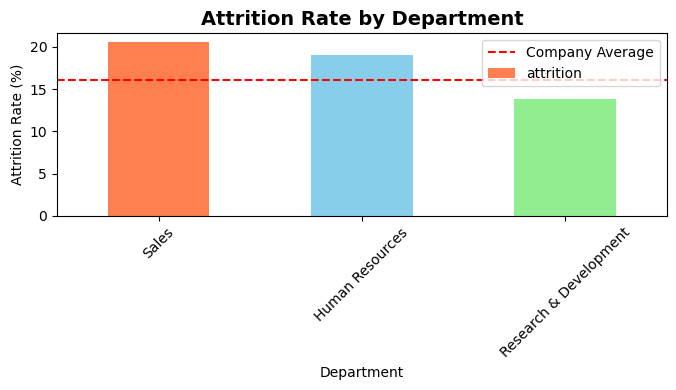

In [9]:
#creating 3 charts
#chart 1
plt.figure(figsize=(7,4))
attrition_dept = df_clean.groupby('department')['attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
attrition_dept.sort_values(ascending=False).plot(kind='bar', color=['coral', 'skyblue', 'lightgreen'])
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=df_clean['attrition'].apply(lambda x: x == 'Yes').mean() * 100, color='red', linestyle='--', label='Company Average')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_attrition_by_dept.png')
plt.show()

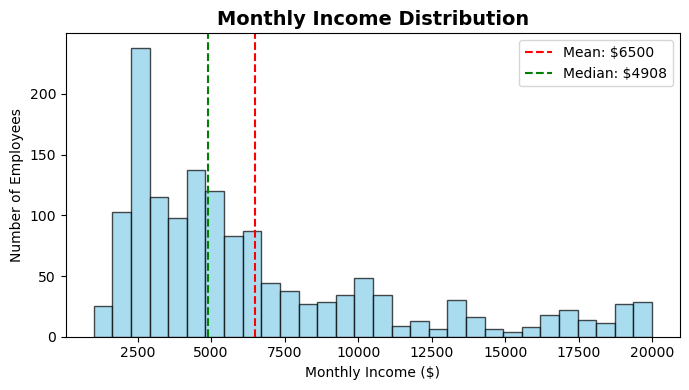

In [11]:
#chart 2
plt.figure(figsize=(7,4))
plt.hist(df_clean['monthlyincome'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Monthly Income Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Number of Employees')
plt.axvline(df_clean['monthlyincome'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["monthlyincome"].mean():.0f}')
plt.axvline(df_clean['monthlyincome'].median(), color='green', linestyle='--', label=f'Median: ${df_clean["monthlyincome"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('chart2_income_distribution.png')
plt.show()

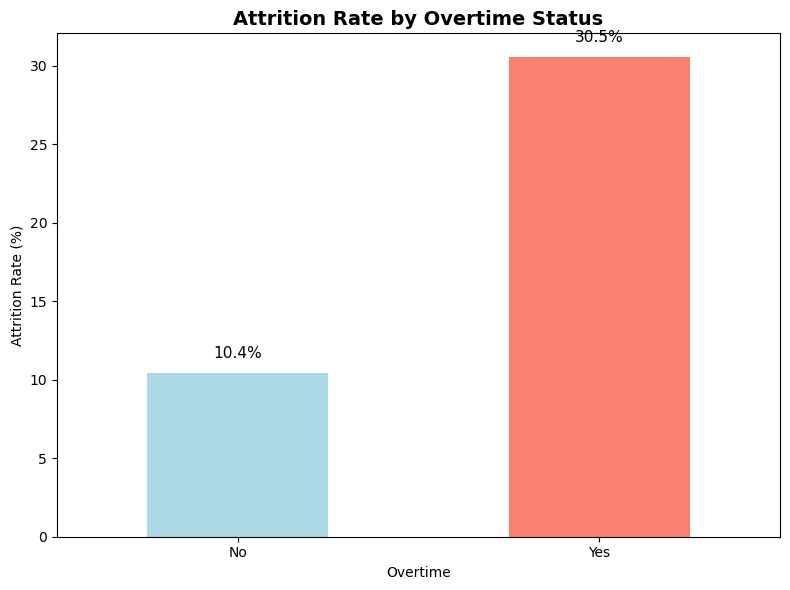

In [12]:
#chart 3
plt.figure(figsize=(8,6))
overtime_attrition = df_clean.groupby('overtime')['attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
overtime_attrition.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Attrition Rate by Overtime Status', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(overtime_attrition):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('chart3_overtime_attrition.png')
plt.show()

CORRELATION ANALYSIS
Correlation Matrix:
                     age  monthlyincome  distancefromhome  education  \
age                 1.00           0.50             -0.00       0.21   
monthlyincome       0.50           1.00             -0.02       0.09   
distancefromhome   -0.00          -0.02              1.00       0.02   
education           0.21           0.09              0.02       1.00   
jobinvolvement      0.03          -0.02              0.01       0.04   
jobsatisfaction    -0.01          -0.01             -0.00      -0.01   
worklifebalance    -0.02           0.03             -0.03       0.01   
totalworkingyears   0.68           0.77              0.01       0.15   
yearsatcompany      0.31           0.51              0.01       0.07   
numcompaniesworked  0.30           0.15             -0.03       0.13   

                    jobinvolvement  jobsatisfaction  worklifebalance  \
age                           0.03            -0.01            -0.02   
monthlyincome         

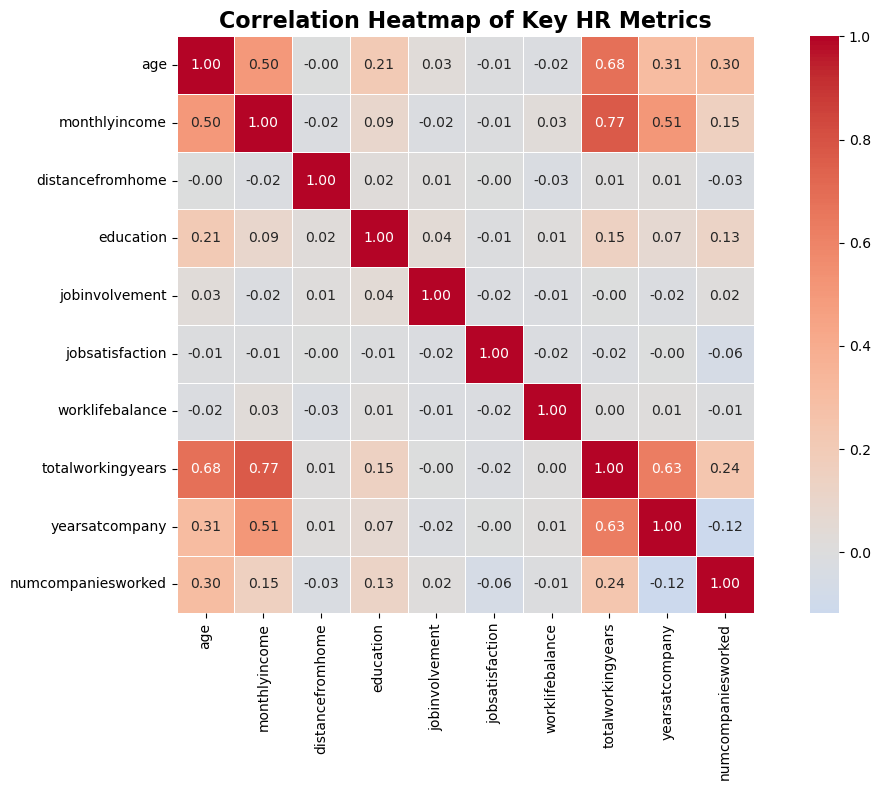

In [13]:
#correlation analysis
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numerical columns for correlation
numeric_cols = ['age', 'monthlyincome', 'distancefromhome', 'education', 
                'jobinvolvement', 'jobsatisfaction', 'worklifebalance', 
                'totalworkingyears', 'yearsatcompany', 'numcompaniesworked']

# Create correlation matrix
correlation_matrix = df_clean[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

print("\n" + "="*60)
print("STRONGEST CORRELATIONS:")
print("="*60)

# Find strongest correlations
for col in correlation_matrix.columns:
    correlations = correlation_matrix[col].drop(col).abs().sort_values(ascending=False)
    if not correlations.empty and correlations.iloc[0] > 0.3:
        print(f"\n{col.upper()} most correlated with:")
        for i in range(min(3, len(correlations))):
            if correlations.iloc[i] > 0.3:
                print(f"  - {correlations.index[i]}: {correlations.iloc[i]:.2f}")

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Key HR Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

In [14]:
import os

# Create outputs directory
os.makedirs('outputs', exist_ok=True)

# Save cleaned dataset
df_clean.to_csv('outputs/cleaned_hr_analytics.csv', index=False)
df_clean.to_excel('outputs/cleaned_hr_analytics.xlsx', index=False)

# Save department summary
dept_summary.to_csv('outputs/department_summary.csv', index=False)

# Save correlation matrix
correlation_matrix.to_csv('outputs/correlation_matrix.csv')

print(" Files exported successfully to 'outputs/' folder!")
print("\nExported files:")
print("  - cleaned_hr_analytics.csv")
print("  - cleaned_hr_analytics.xlsx")
print("  - department_summary.csv")
print("  - correlation_matrix.csv")
print("\n Charts saved as PNG files:")
print("  - chart1_attrition_by_dept.png")
print("  - chart2_income_distribution.png")
print("  - chart3_overtime_attrition.png")
print("  - heatmap.png")

 Files exported successfully to 'outputs/' folder!

Exported files:
  - cleaned_hr_analytics.csv
  - cleaned_hr_analytics.xlsx
  - department_summary.csv
  - correlation_matrix.csv

 Charts saved as PNG files:
  - chart1_attrition_by_dept.png
  - chart2_income_distribution.png
  - chart3_overtime_attrition.png
  - heatmap.png
